# 📊 Evaluasi Q-Table DDA - Convergence Test & Reward Analysis

Notebook ini memproses output dari `QTableLogger.cs` (Unity) untuk mengevaluasi apakah Q-table sudah optimal.

## Referensi:
- **Watkins, C.J.C.H. & Dayan, P. (1992)** - *Q-learning* (Machine Learning, 8, 279–292) — bukti teoritis konvergensi Q-learning
- **Sutton, R.S. & Barto, A.G. (2018)** - *Reinforcement Learning: An Introduction* (2nd ed., MIT Press) — Ch.6 untuk Temporal Difference Learning
- **Yannakakis, G.N. & Togelius, J. (2018)** - *Artificial Intelligence and Games* — Ch.5 untuk DDA berbasis RL

## Test yang dilakukan:
1. **Convergence Test** — Max Delta Q per snapshot (nilai harus mendekati 0)
2. **Cumulative Reward Plot** — Reward per episode (harus meningkat dan stabil)
3. **Q-Value Distribution** — Distribusi nilai Q di Q-table
4. **Policy Stability** — Persentase state yang best action-nya tidak berubah

In [12]:
# Install dependencies jika belum ada
# !pip install matplotlib seaborn numpy pandas scipy

In [13]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import linregress
from pathlib import Path

# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load Data dari Unity

In [14]:
JSON_PATH = 'C:\\Users\\Leily\\AppData\\LocalLow\\SaltStudio\\Lost In Time\\qtable_evaluation_120ebfb8.json' 

USE_DUMMY_DATA = False 

def generate_dummy_data(n_episodes=200, n_states=16, n_actions=3, snapshot_interval=10):
    """Generate data dummy yang mensimulasikan Q-learning yang konvergen."""
    import random
    random.seed(42)
    np.random.seed(42)
    
    # Simulasi Q-table yang semakin konvergen
    true_q = np.random.uniform(-1, 1, (n_states, n_actions))
    current_q = np.zeros((n_states, n_actions))
    
    episodes = []
    snapshots = []
    difficulties = ['Easy', 'Normal', 'Hard']
    
    for ep in range(1, n_episodes + 1):
        # Reward meningkat seiring training (dengan noise)
        base_reward = -5 + (ep / n_episodes) * 15
        reward = base_reward + np.random.normal(0, 2)
        
        hp_ratio = min(1.0, max(0.1, 0.3 + (ep / n_episodes) * 0.5 + np.random.normal(0, 0.1)))
        difficulty = difficulties[min(2, int(ep / (n_episodes / 3)))]
        
        episodes.append({
            'episode': ep,
            'totalReward': round(reward, 4),
            'episodeLength': int(np.random.randint(5, 20)),
            'playerHPRatio': round(hp_ratio, 4),
            'difficulty': difficulty,
            'timestamp': 1700000000000 + ep * 30000
        })
        
        # Update Q-table (simulasi konvergensi)
        if ep % snapshot_interval == 0:
            alpha = 0.3 * (0.99 ** (ep // snapshot_interval))
            prev_q = current_q.copy()
            current_q += alpha * (true_q - current_q) + np.random.normal(0, 0.01, current_q.shape)
            
            max_delta = float(np.max(np.abs(current_q - prev_q)))
            mean_abs_q = float(np.mean(np.abs(current_q)))
            
            states = []
            for s in range(n_states):
                q_vals = current_q[s].tolist()
                states.append({
                    'state': f'state_{s:02d}',
                    'qValues': q_vals,
                    'bestAction': int(np.argmax(q_vals))
                })
            
            snapshots.append({
                'episode': ep,
                'maxDeltaQ': round(max_delta, 6),
                'meanAbsQ': round(mean_abs_q, 6),
                'stdQ': round(float(np.std(current_q)), 6),
                'states': states
            })
    
    return {
        'gameVersion': '1.0.0',
        'sessionId': 'dummy001',
        'startTime': '2025-01-01 00:00:00',
        'episodes': episodes,
        'qtableSnapshots': snapshots
    }

# Load data
if USE_DUMMY_DATA:
    data = generate_dummy_data(n_episodes=1000, n_states=81, n_actions=3)
    print('✓ Menggunakan data DUMMY')
else:
    with open(JSON_PATH, 'r') as f:
        data = json.load(f)
    print(f'✓ Data dimuat dari: {JSON_PATH}')

# Parse ke DataFrame
df_episodes = pd.DataFrame(data['episodes'])
df_snapshots = pd.DataFrame([
    {
        'episode': s['episode'],
        'maxDeltaQ': s['maxDeltaQ'],
        'meanAbsQ': s['meanAbsQ'],
        'stdQ': s['stdQ'],
        'n_states': len(s['states'])
    }
    for s in data['qtableSnapshots']
])

print(f"\n📦 Total episodes   : {len(df_episodes)}")
print(f"📸 Total snapshots  : {len(df_snapshots)}")
print(f"🎮 Session ID       : {data.get('sessionId', 'N/A')}")
print(f"🎮 Hyperparameters  : {data.get('hyperparameters', 'N/A')}")


print(f"\nEpisode stats:")
df_episodes[['totalReward', 'episodeLength', 'playerHPRatio']].describe().round(3)

✓ Data dimuat dari: C:\Users\Leily\AppData\LocalLow\SaltStudio\Lost In Time\qtable_evaluation_120ebfb8.json

📦 Total episodes   : 15000
📸 Total snapshots  : 300
🎮 Session ID       : 120ebfb8
🎮 Hyperparameters  : {'alpha': 0.009999999776482582, 'gamma': 0.699999988079071, 'epsilonStart': 0.30000001192092896, 'epsilonEnd': 0.05000000074505806, 'epsilonDecay': 0.9990000128746033, 'totalEpisodes': 15000}

Episode stats:


,totalReward,episodeLength,playerHPRatio
count,15000.000,15000.0,15000.000
mean,0.669,1.0,0.513
std,1.470,0.0,0.298
min,-2.000,1.0,0.010
25%,-0.700,1.0,0.241
50%,0.500,1.0,0.517
75%,2.300,1.0,0.783
max,2.800,1.0,1.000


## 2. Convergence Test — Max Delta Q

Action 0 : 19
Action 1 : 4
Action 2 : 4
Action 0 : 14
Action 1 : 7
Action 2 : 6
Action 0 : 14
Action 1 : 3
Action 2 : 10
Action 0 : 12
Action 1 : 4
Action 2 : 11
Action 0 : 12
Action 1 : 4
Action 2 : 11
Action 0 : 14
Action 1 : 2
Action 2 : 11
Action 0 : 14
Action 1 : 2
Action 2 : 11
Action 0 : 13
Action 1 : 2
Action 2 : 12
Action 0 : 13
Action 1 : 2
Action 2 : 12
Action 0 : 13
Action 1 : 2
Action 2 : 12
Action 0 : 13
Action 1 : 2
Action 2 : 12
Action 0 : 13
Action 1 : 2
Action 2 : 12
Action 0 : 13
Action 1 : 2
Action 2 : 12
Action 0 : 13
Action 1 : 2
Action 2 : 12
Action 0 : 13
Action 1 : 2
Action 2 : 12
Action 0 : 13
Action 1 : 2
Action 2 : 12
Action 0 : 12
Action 1 : 2
Action 2 : 13
Action 0 : 12
Action 1 : 2
Action 2 : 13
Action 0 : 12
Action 1 : 2
Action 2 : 13
Action 0 : 12
Action 1 : 2
Action 2 : 13
Action 0 : 12
Action 1 : 2
Action 2 : 13
Action 0 : 12
Action 1 : 2
Action 2 : 13
Action 0 : 12
Action 1 : 2
Action 2 : 13
Action 0 : 12
Action 1 : 2
Action 2 : 13
Action 0 : 12
Acti

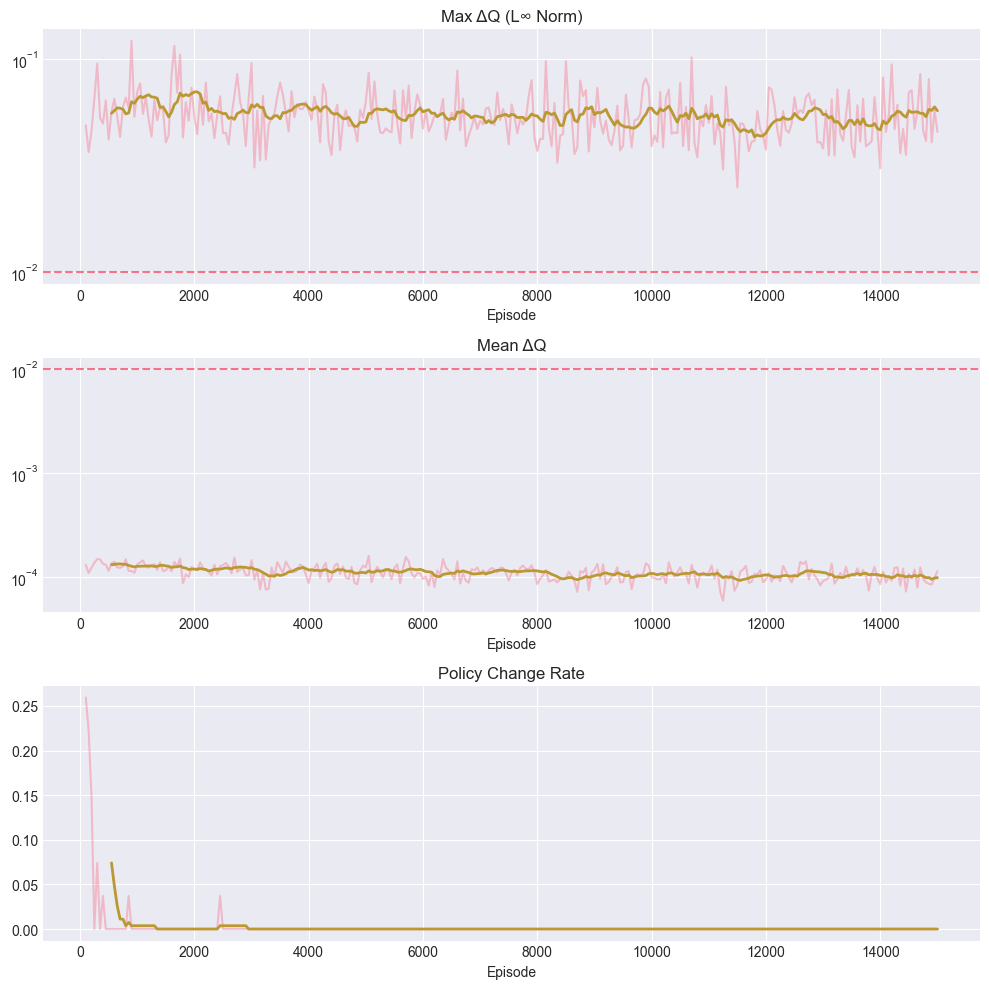


CONVERGENCE ANALYSIS RESULT
Mean ΔQ (final): 0.000098
Policy change rate (final): 0.000000
Status: POLICY CONVERGED


In [15]:
# ================================================================
# Q-LEARNING CONVERGENCE ANALYSIS
# Evaluasi stabilitas Q-table berdasarkan:
# 1. Max ΔQ (L∞ norm)
# 2. Mean ΔQ
# 3. Policy Stability
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EPS_CONVERGENCE = 0.01
WINDOW = 10

episodes = []
max_deltas = []
mean_deltas = []
policy_changes = []

prev_q = None
prev_policy = None
prev_ep = None

for snap in data['qtableSnapshots']:

    ep = snap['episode']
    
    # reconstruct Q matrix
    q_values = np.array([s['qValues'] for s in snap['states']])
    policy = np.argmax(q_values, axis=1)
    unique, counts = np.unique(policy, return_counts=True)
    for a,c in zip(unique,counts):
        print("Action", a, ":", c)
    if prev_q is not None:

        delta = np.abs(q_values - prev_q)

        max_delta = np.max(delta)
        mean_delta = np.mean(delta) / (ep - prev_ep) if (ep - prev_ep) > 0 else 0

        policy_change = np.mean(policy != prev_policy)

        max_deltas.append(max_delta)
        mean_deltas.append(mean_delta)
        policy_changes.append(policy_change)
        episodes.append(ep)

    prev_q = q_values
    prev_policy = policy
    prev_ep = ep
df_conv = pd.DataFrame({
    "episode": episodes,
    "max_delta": max_deltas,
    "mean_delta": mean_deltas,
    "policy_change": policy_changes
})

# moving averages
df_conv["max_delta_ma"] = df_conv["max_delta"].rolling(WINDOW).mean()
df_conv["mean_delta_ma"] = df_conv["mean_delta"].rolling(WINDOW).mean()
df_conv["policy_change_ma"] = df_conv["policy_change"].rolling(WINDOW).mean()

# ================================================================
# VISUALIZATION
# ================================================================

fig, axes = plt.subplots(3,1, figsize=(10,10))

# --- Max Delta Q ---
axes[0].plot(df_conv["episode"], df_conv["max_delta"], alpha=0.4)
axes[0].plot(df_conv["episode"], df_conv["max_delta_ma"], linewidth=2)
axes[0].axhline(EPS_CONVERGENCE, linestyle="--")
axes[0].set_title("Max ΔQ (L∞ Norm)")
axes[0].set_yscale("log")

# --- Mean Delta Q ---
axes[1].plot(df_conv["episode"], df_conv["mean_delta"], alpha=0.4)
axes[1].plot(df_conv["episode"], df_conv["mean_delta_ma"], linewidth=2)
axes[1].axhline(EPS_CONVERGENCE, linestyle="--")
axes[1].set_title("Mean ΔQ")
axes[1].set_yscale("log")

# --- Policy Stability ---
axes[2].plot(df_conv["episode"], df_conv["policy_change"], alpha=0.4)
axes[2].plot(df_conv["episode"], df_conv["policy_change_ma"], linewidth=2)
axes[2].set_title("Policy Change Rate")

for ax in axes:
    ax.set_xlabel("Episode")

plt.tight_layout()
plt.savefig('convergence_test2.png', dpi=150, bbox_inches='tight')
plt.show()

# ================================================================
# AUTOMATIC CONVERGENCE CHECK
# ================================================================

last_mean_delta = df_conv["mean_delta_ma"].iloc[-1]
last_policy_change = df_conv["policy_change_ma"].iloc[-1]

print("\n==============================")
print("CONVERGENCE ANALYSIS RESULT")
print("==============================")

print(f"Mean ΔQ (final): {last_mean_delta:.6f}")
print(f"Policy change rate (final): {last_policy_change:.6f}")

if last_policy_change < 0.01:
    print("Status: POLICY CONVERGED")
elif last_mean_delta < EPS_CONVERGENCE:
    print("Status: Q-table CONVERGED")
else:
    print("Status: STILL LEARNING")

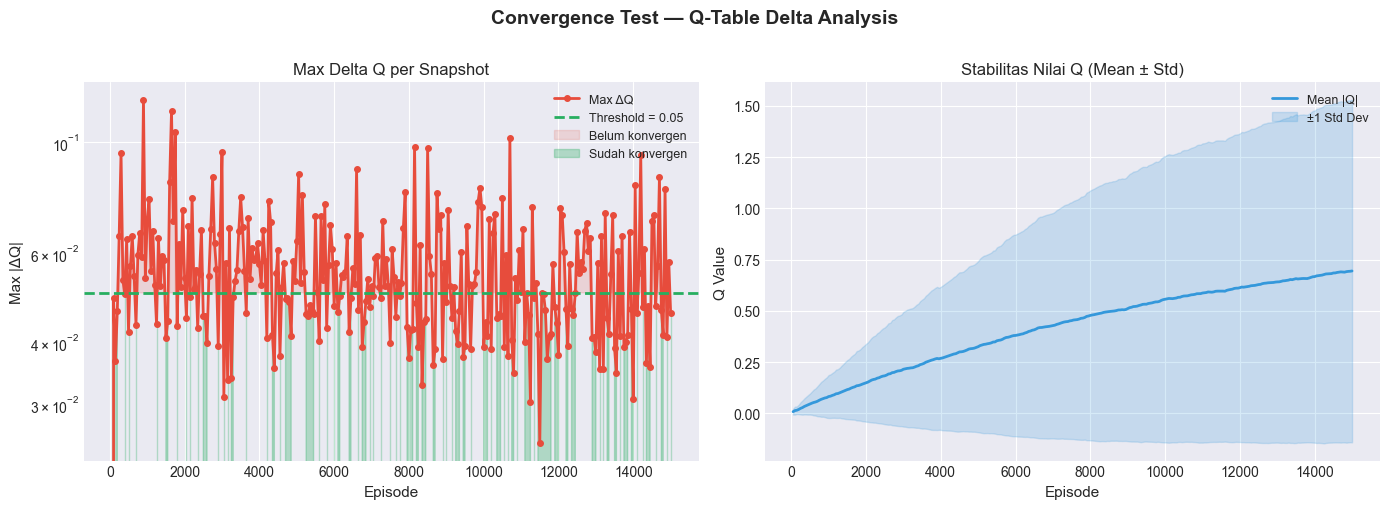


HASIL CONVERGENCE TEST
Max ΔQ (akhir)     : 0.045516
Max ΔQ (5 snapshot terakhir): 0.053108 (rata-rata)
Threshold          : 0.05

Status: ✅ Q-TABLE SUDAH KONVERGEN (OPTIMAL)


In [16]:
# =====================================================================
# CONVERGENCE TEST
# Referensi: Watkins & Dayan (1992) — Q-learning konvergen ke Q*
# jika semua state-action pairs dikunjungi dan learning rate
# memenuhi kondisi Robbins-Monro.
#
# Interpretasi:
# - Max Delta Q -> 0  : Q-table sudah konvergen (OPTIMAL)
# - Max Delta Q stabil tinggi : masih belajar / belum konvergen
# =====================================================================

CONVERGENCE_THRESHOLD = 0.05  # nilai delta Q yang dianggap "cukup konvergen"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Convergence Test — Q-Table Delta Analysis', fontsize=14, fontweight='bold', y=1.01)

# --- Plot 1: Max Delta Q per snapshot ---
ax1 = axes[0]
ax1.plot(df_snapshots['episode'], df_snapshots['maxDeltaQ'],
         color='#E74C3C', linewidth=2, marker='o', markersize=4, label='Max ΔQ')
ax1.axhline(y=CONVERGENCE_THRESHOLD, color='#27AE60', linestyle='--', linewidth=2,
            label=f'Threshold = {CONVERGENCE_THRESHOLD}')
ax1.fill_between(df_snapshots['episode'], df_snapshots['maxDeltaQ'], CONVERGENCE_THRESHOLD,
                 where=df_snapshots['maxDeltaQ'] > CONVERGENCE_THRESHOLD,
                 alpha=0.15, color='#E74C3C', label='Belum konvergen')
ax1.fill_between(df_snapshots['episode'], 0, df_snapshots['maxDeltaQ'],
                 where=df_snapshots['maxDeltaQ'] <= CONVERGENCE_THRESHOLD,
                 alpha=0.3, color='#27AE60', label='Sudah konvergen')

ax1.set_xlabel('Episode', fontsize=11)
ax1.set_ylabel('Max |ΔQ|', fontsize=11)
ax1.set_title('Max Delta Q per Snapshot', fontsize=12)
ax1.legend(fontsize=9)
ax1.set_yscale('log')  # skala log lebih mudah dibaca untuk konvergensi

# --- Plot 2: Mean & Std Q Values (stabilitas Q-table) ---
ax2 = axes[1]
ax2.plot(df_snapshots['episode'], df_snapshots['meanAbsQ'],
         color='#3498DB', linewidth=2, label='Mean |Q|')
ax2.fill_between(
    df_snapshots['episode'],
    df_snapshots['meanAbsQ'] - df_snapshots['stdQ'],
    df_snapshots['meanAbsQ'] + df_snapshots['stdQ'],
    alpha=0.2, color='#3498DB', label='±1 Std Dev'
)
ax2.set_xlabel('Episode', fontsize=11)
ax2.set_ylabel('Q Value', fontsize=11)
ax2.set_title('Stabilitas Nilai Q (Mean ± Std)', fontsize=12)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('convergence_test.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Kesimpulan Otomatis ---
last_5_deltas = df_snapshots['maxDeltaQ'].tail(5)
final_delta = df_snapshots['maxDeltaQ'].iloc[-1]
converged = final_delta < CONVERGENCE_THRESHOLD

print('\n' + '='*55)
print('HASIL CONVERGENCE TEST')
print('='*55)
print(f'Max ΔQ (akhir)     : {final_delta:.6f}')
print(f'Max ΔQ (5 snapshot terakhir): {last_5_deltas.mean():.6f} (rata-rata)')
print(f'Threshold          : {CONVERGENCE_THRESHOLD}')
print(f'\nStatus: {"✅ Q-TABLE SUDAH KONVERGEN (OPTIMAL)" if converged else "❌ Q-TABLE BELUM KONVERGEN (MASIH BELAJAR)"}')
if not converged:
    print('  → Saran: Perbanyak episode training atau turunkan learning rate.')

## 3. Cumulative Reward Plot

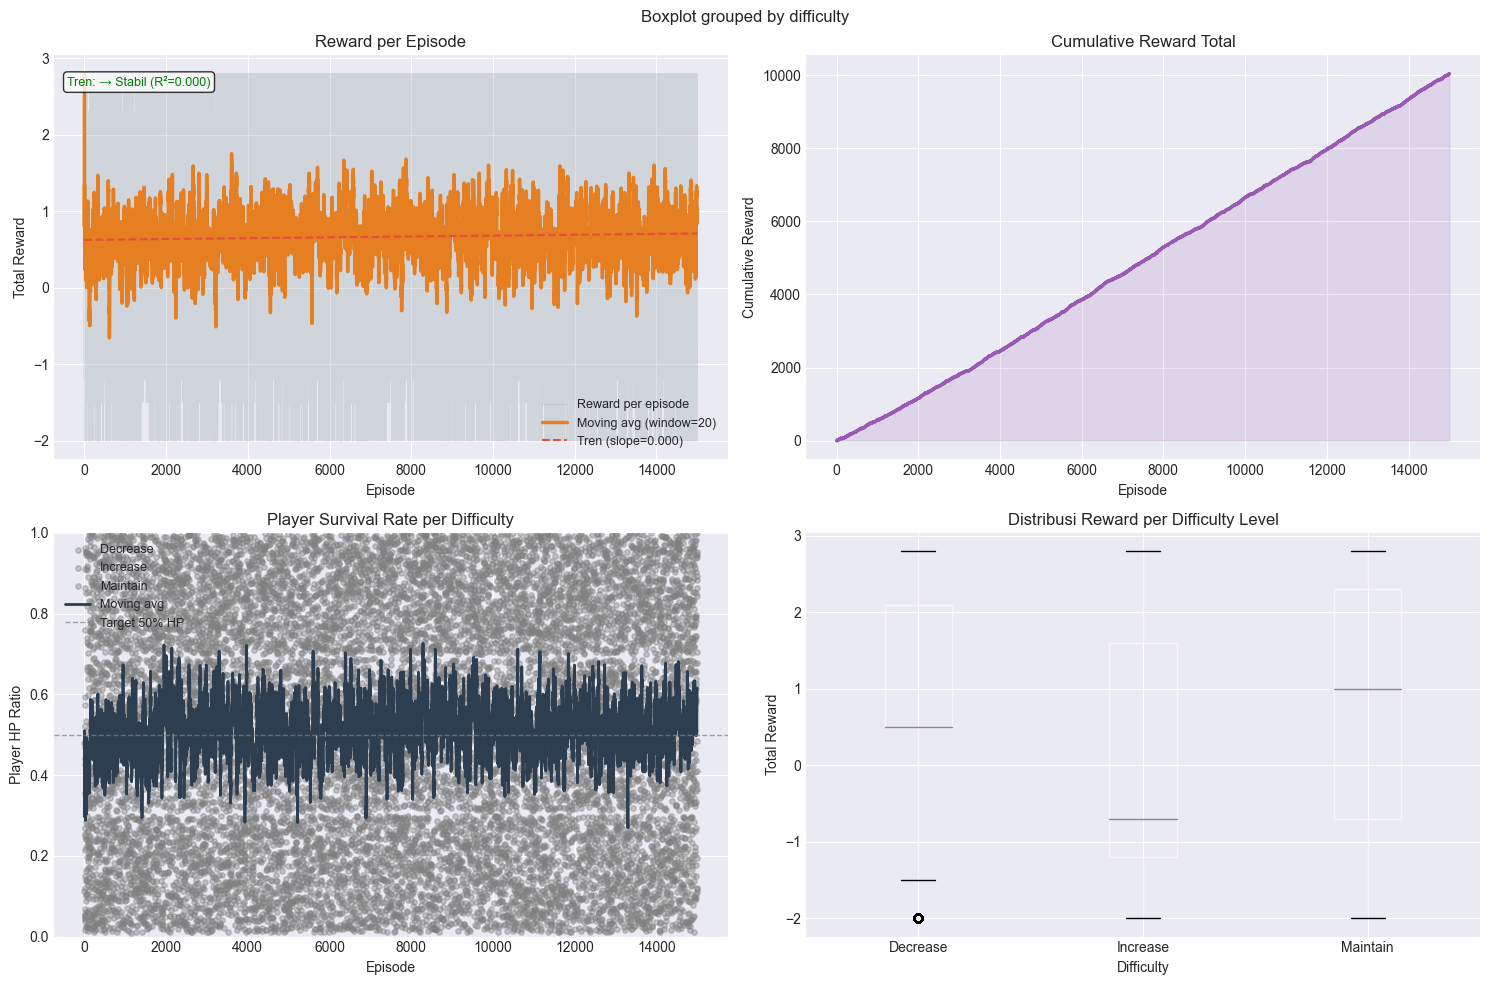


ANALISIS CUMULATIVE REWARD
Rata-rata reward (50 episode pertama)  : 0.654
Rata-rata reward (50 episode terakhir) : 0.684
Peningkatan                            : +4.6%
Slope trendline                        : +0.0000

Status: ✅ Agen belajar dengan baik


In [17]:
# =====================================================================
# CUMULATIVE REWARD PLOT
# Referensi: Sutton & Barto (2018) Ch.1 — reward hypothesis:
# agen yang optimal memaksimalkan expected cumulative reward.
#
# Interpretasi:
# - Kurva naik konsisten = agen belajar dengan baik
# - Kurva mendatar = agen sudah menemukan policy optimal
# - Kurva naik-turun = agen masih eksplorasi
# =====================================================================

WINDOW = 20  # window untuk moving average

df_episodes['cumulative_reward'] = df_episodes['totalReward'].cumsum()
df_episodes['reward_ma'] = df_episodes['totalReward'].rolling(window=WINDOW, min_periods=1).mean()
df_episodes['hp_ma'] = df_episodes['playerHPRatio'].rolling(window=WINDOW, min_periods=1).mean()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Cumulative Reward & Learning Progress', fontsize=14, fontweight='bold')

# --- Plot 1: Reward per episode + moving average ---
ax = axes[0, 0]
ax.plot(df_episodes['episode'], df_episodes['totalReward'],
        alpha=0.3, color='#95A5A6', linewidth=1, label='Reward per episode')
ax.plot(df_episodes['episode'], df_episodes['reward_ma'],
        color='#E67E22', linewidth=2.5, label=f'Moving avg (window={WINDOW})')

# Trendline
slope, intercept, r, p, _ = linregress(df_episodes['episode'], df_episodes['totalReward'])
trendline = slope * df_episodes['episode'] + intercept
ax.plot(df_episodes['episode'], trendline,
        color='#E74C3C', linestyle='--', linewidth=1.5, label=f'Tren (slope={slope:.3f})')

ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.set_title('Reward per Episode')
ax.legend(fontsize=9)

# Annotasi tren
trend_label = '↑ Meningkat' if slope > 0.05 else ('→ Stabil' if abs(slope) <= 0.05 else '↓ Menurun')
ax.text(0.02, 0.95, f'Tren: {trend_label} (R²={r**2:.3f})',
        transform=ax.transAxes, fontsize=9,
        color='green' if slope > 0 else 'red',
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# --- Plot 2: Cumulative reward ---
ax2 = axes[0, 1]
ax2.plot(df_episodes['episode'], df_episodes['cumulative_reward'],
         color='#9B59B6', linewidth=2.5)
ax2.fill_between(df_episodes['episode'], 0, df_episodes['cumulative_reward'],
                 alpha=0.15, color='#9B59B6')
ax2.set_xlabel('Episode')
ax2.set_ylabel('Cumulative Reward')
ax2.set_title('Cumulative Reward Total')

# --- Plot 3: Player HP Ratio (indikator keseimbangan DDA) ---
ax3 = axes[1, 0]
colors = {'Easy': '#2ECC71', 'Normal': '#F39C12', 'Hard': '#E74C3C'}
for diff, group in df_episodes.groupby('difficulty'):
    ax3.scatter(group['episode'], group['playerHPRatio'],
                alpha=0.4, s=15, color=colors.get(diff, 'gray'), label=diff)
ax3.plot(df_episodes['episode'], df_episodes['hp_ma'],
         color='#2C3E50', linewidth=2, label=f'Moving avg')
ax3.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Target 50% HP')
ax3.set_xlabel('Episode')
ax3.set_ylabel('Player HP Ratio')
ax3.set_title('Player Survival Rate per Difficulty')
ax3.legend(fontsize=9)
ax3.set_ylim(0, 1)

# --- Plot 4: Reward distribution per difficulty ---
ax4 = axes[1, 1]
diff_order = [d for d in ['Easy', 'Normal', 'Hard'] if d in df_episodes['difficulty'].unique()]

df_plot = df_episodes.copy()
if diff_order:
    df_plot['difficulty'] = pd.Categorical(df_plot['difficulty'], categories=diff_order, ordered=True)
    df_plot = df_plot.sort_values('difficulty')

df_plot.boxplot(column='totalReward', by='difficulty', ax=ax4)
ax4.set_title('Distribusi Reward per Difficulty Level')
ax4.set_xlabel('Difficulty')
ax4.set_ylabel('Total Reward')
plt.sca(ax4)  # Fix suptitle dari boxplot

plt.tight_layout()
plt.savefig('cumulative_reward.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Summary ---
print('\n' + '='*55)
print('ANALISIS CUMULATIVE REWARD')
print('='*55)
first_half = df_episodes['totalReward'].iloc[:len(df_episodes)//2].mean()
second_half = df_episodes['totalReward'].iloc[len(df_episodes)//2:].mean()
improvement = ((second_half - first_half) / abs(first_half) * 100) if first_half != 0 else 0

print(f'Rata-rata reward (50 episode pertama)  : {first_half:.3f}')
print(f'Rata-rata reward (50 episode terakhir) : {second_half:.3f}')
print(f'Peningkatan                            : {improvement:+.1f}%')
print(f'Slope trendline                        : {slope:+.4f}')
print(f'\nStatus: {"✅ Agen belajar dengan baik" if slope > 0 else "⚠️ Agen tidak menunjukkan peningkatan"}')

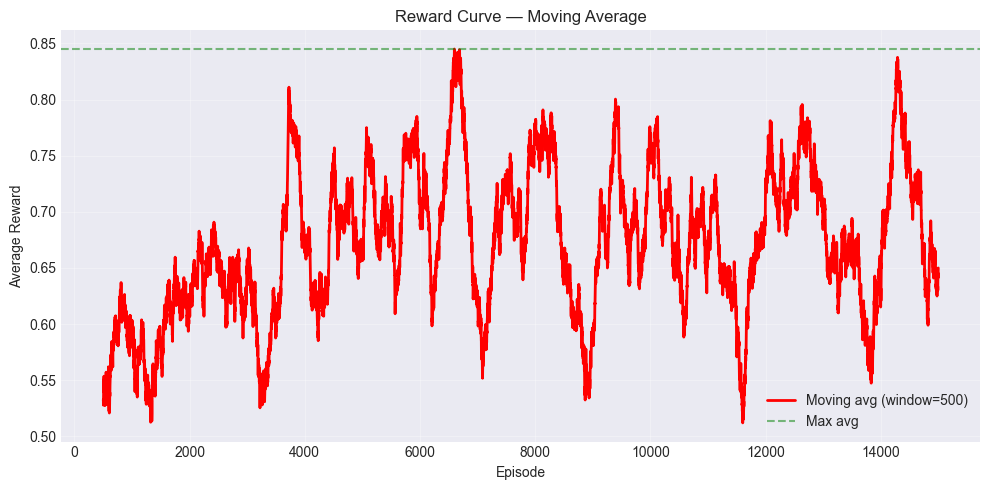

Reward trend slope: 5.593778633645923e-06
Average reward (last 1000 episodes): 0.7047999749183654
Reward std: 1.4479837414600114


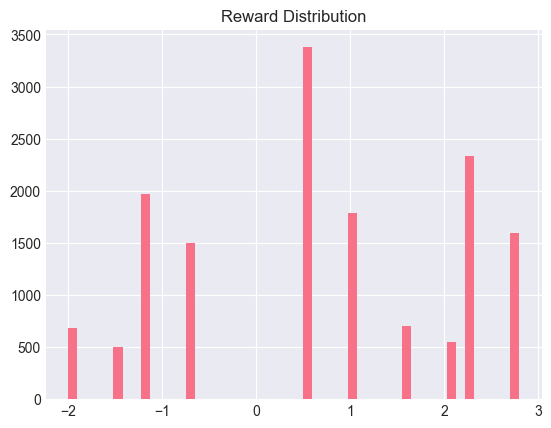

In [18]:
# Ambil data reward per episode
rewards = [ep['totalReward'] for ep in data['episodes']]

# Hitung moving average dengan window 500 episode
window = 500
moving_avg = pd.Series(rewards).rolling(window=window).mean()

plt.figure(figsize=(10, 5))
# plt.plot(rewards, alpha=0.2, color='gray', label='Reward per episode')
plt.plot(moving_avg, color='red', linewidth=2, label=f'Moving avg (window={window})')
plt.axhline(y=max(moving_avg.dropna()), color='green', linestyle='--', alpha=0.5, label='Max avg')
plt.xlabel('Episode')
plt.ylabel('Average Reward')
plt.title('Reward Curve — Moving Average')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('reward_curve.png', dpi=150, bbox_inches='tight')
plt.show()

plt.hist(rewards, bins=50)
plt.title("Reward Distribution")

from scipy.stats import linregress

slope, _, _, _, _ = linregress(range(len(rewards)), rewards)
print("Reward trend slope:", slope)

reward_mean = np.mean(rewards[-1000:])
reward_std = np.std(rewards[-1000:])

print("Average reward (last 1000 episodes):", reward_mean)
print("Reward std:", reward_std)

## 4. Policy Stability Test

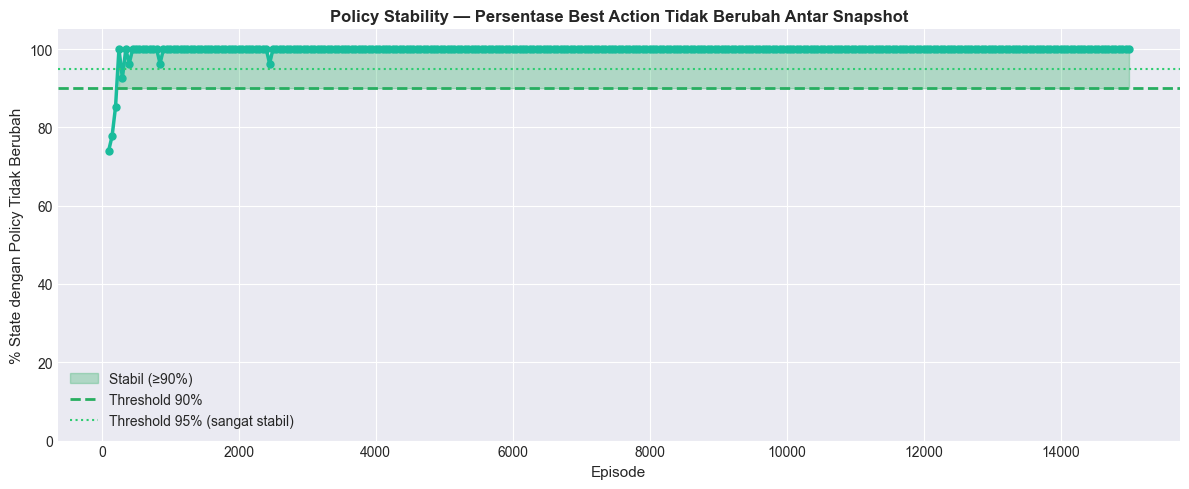


HASIL POLICY STABILITY TEST
Stabilitas akhir          : 100.0%
Rata-rata 5 snapshot terakhir : 100.0%

Status: ✅ Policy STABIL (optimal)


In [19]:
# =====================================================================
# POLICY STABILITY TEST
# Mengecek berapa persen state yang best action-nya TIDAK berubah
# antar snapshot. Policy yang stabil = Q-table sudah optimal.
# =====================================================================

snapshots = data['qtableSnapshots']
stability_data = []

for i in range(1, len(snapshots)):
    prev_snap = {s['state']: s['bestAction'] for s in snapshots[i-1]['states']}
    curr_snap = {s['state']: s['bestAction'] for s in snapshots[i]['states']}
    
    common_states = set(prev_snap.keys()) & set(curr_snap.keys())
    if not common_states:
        continue
    
    unchanged = sum(1 for s in common_states if prev_snap[s] == curr_snap[s])
    stability_pct = unchanged / len(common_states) * 100
    
    stability_data.append({
        'episode': snapshots[i]['episode'],
        'stability_pct': stability_pct,
        'unchanged_states': unchanged,
        'total_states': len(common_states)
    })

df_stability = pd.DataFrame(stability_data)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_stability['episode'], df_stability['stability_pct'],
        color='#1ABC9C', linewidth=2.5, marker='o', markersize=5)
ax.fill_between(df_stability['episode'], 90, df_stability['stability_pct'],
                where=df_stability['stability_pct'] >= 90,
                alpha=0.3, color='#27AE60', label='Stabil (≥90%)')
ax.axhline(y=90, color='#27AE60', linestyle='--', linewidth=2, label='Threshold 90%')
ax.axhline(y=95, color='#2ECC71', linestyle=':', linewidth=1.5, label='Threshold 95% (sangat stabil)')

ax.set_xlabel('Episode', fontsize=11)
ax.set_ylabel('% State dengan Policy Tidak Berubah', fontsize=11)
ax.set_title('Policy Stability — Persentase Best Action Tidak Berubah Antar Snapshot', fontsize=12, fontweight='bold')
ax.set_ylim(0, 105)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('policy_stability.png', dpi=150, bbox_inches='tight')
plt.show()

final_stability = df_stability['stability_pct'].iloc[-1] if not df_stability.empty else 0
avg_last_5 = df_stability['stability_pct'].tail(5).mean() if not df_stability.empty else 0

print('\n' + '='*55)
print('HASIL POLICY STABILITY TEST')
print('='*55)
print(f'Stabilitas akhir          : {final_stability:.1f}%')
print(f'Rata-rata 5 snapshot terakhir : {avg_last_5:.1f}%')
status = '✅ Policy STABIL (optimal)' if avg_last_5 >= 90 else '⚠️ Policy masih berubah'
print(f'\nStatus: {status}')

## 5. Q-Value Heatmap

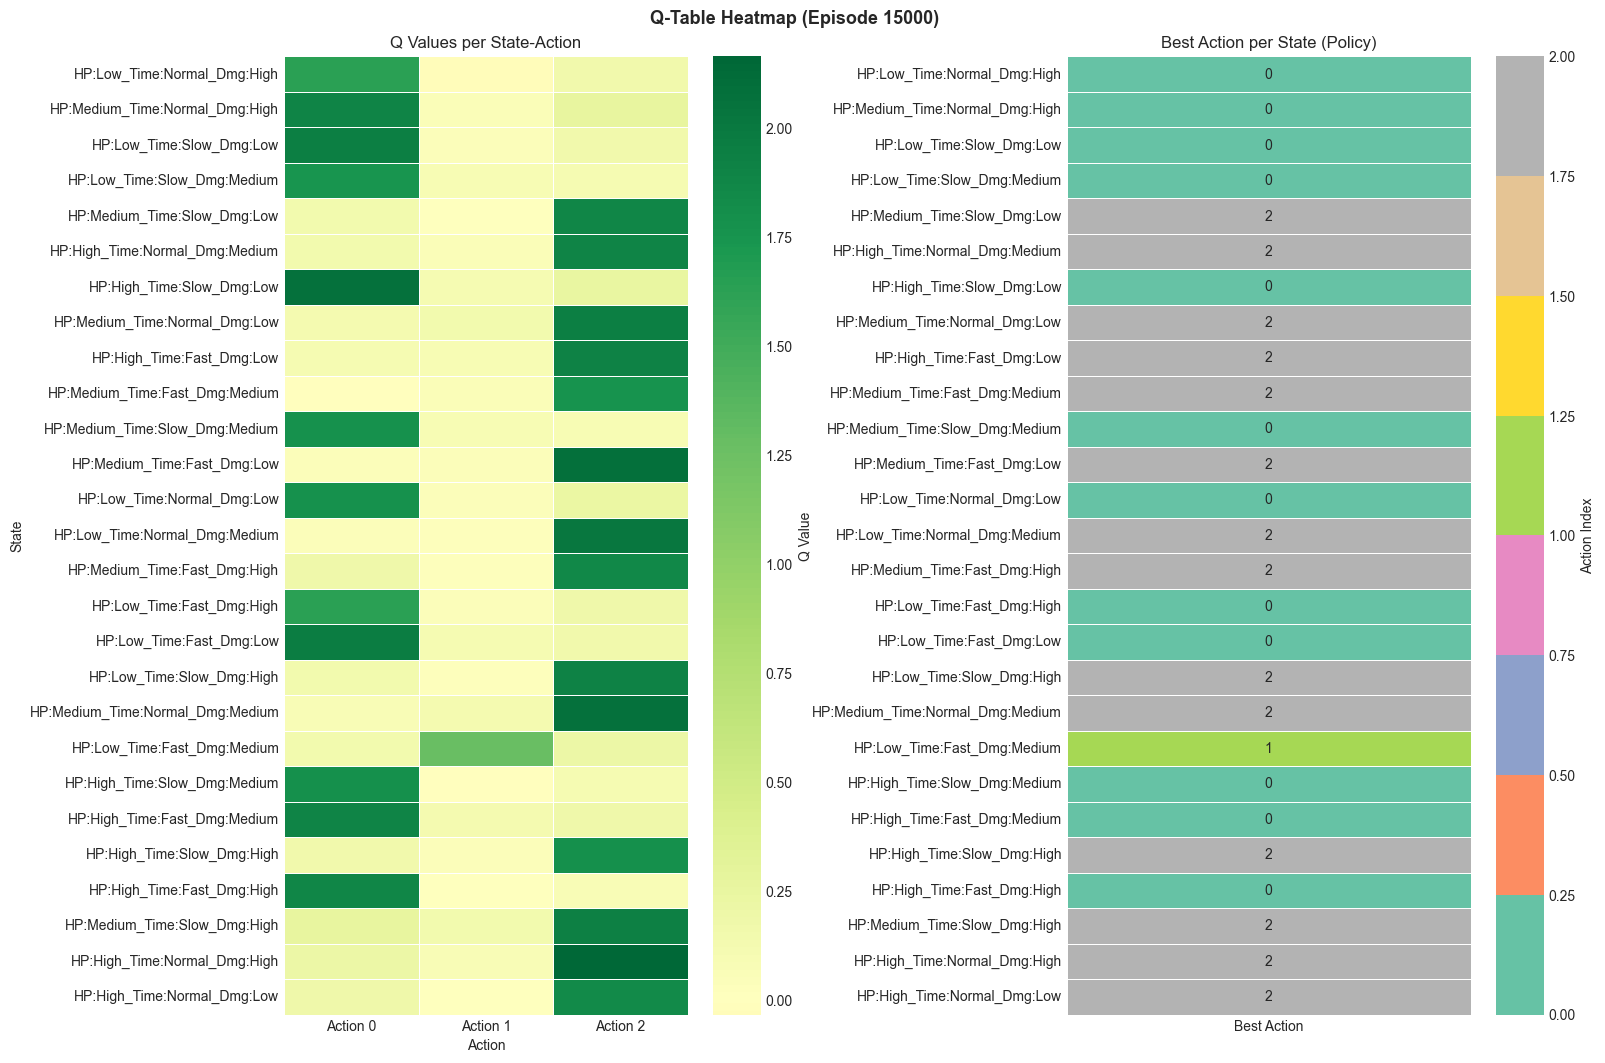

Q-Table shape: (27, 3) (27 states × 3 actions)
Q variance: 0.7012491062252716
✅ Semua state sudah memiliki Q values yang terisi.


In [20]:
# =====================================================================
# Q-VALUE HEATMAP
# Visualisasi nilai Q di Q-table pada snapshot terakhir.
# Berguna untuk melihat apakah ada state yang belum dijelajahi (nilai ~0)
# =====================================================================

last_snapshot = data['qtableSnapshots'][-1]
states = last_snapshot['states']

state_names = [s['state'] for s in states]
n_actions = len(states[0]['qValues'])
action_names = [f'Action {i}' for i in range(n_actions)]

q_matrix = np.array([s['qValues'] for s in states])  # shape: (n_states, n_actions)

fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(state_names) * 0.4)))
fig.suptitle(f'Q-Table Heatmap (Episode {last_snapshot["episode"]})',
             fontsize=13, fontweight='bold')

# Heatmap Q values
sns.heatmap(q_matrix, ax=axes[0],
            xticklabels=action_names,
            yticklabels=state_names,
            annot=len(state_names) <= 20,  # tampilkan angka jika state tidak terlalu banyak
            fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5,
            cbar_kws={'label': 'Q Value'})
axes[0].set_title('Q Values per State-Action')
axes[0].set_xlabel('Action')
axes[0].set_ylabel('State')

# Heatmap best action
best_actions = np.array([[s['bestAction']] for s in states])
sns.heatmap(best_actions, ax=axes[1],
            xticklabels=['Best Action'],
            yticklabels=state_names,
            annot=True, fmt='d',
            cmap='Set2', linewidths=0.5,
            cbar_kws={'label': 'Action Index'})
axes[1].set_title('Best Action per State (Policy)')

plt.tight_layout()
plt.savefig('qtable_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Q-Table shape: {q_matrix.shape} ({len(state_names)} states × {n_actions} actions)')
q_values = np.array([s['qValues'] for s in last_snapshot['states']])
print("Q variance:", np.var(q_values))
# Deteksi unvisited states (nilai Q sangat kecil / ~0)
unvisited = [state_names[i] for i, row in enumerate(q_matrix) if np.max(np.abs(row)) < 0.001]
if unvisited:
    print(f'⚠️ State yang mungkin belum dijelajahi ({len(unvisited)}): {unvisited[:10]}')
else:
    print('✅ Semua state sudah memiliki Q values yang terisi.')

## 6. Ringkasan Evaluasi

In [21]:
# =====================================================================
# RINGKASAN EVALUASI LENGKAP
# =====================================================================
print('=' * 60)
print('           RINGKASAN EVALUASI Q-TABLE DDA')
print('=' * 60)
print(f'Session ID    : {data.get("sessionId", "N/A")}')
print(f'Total episode : {len(df_episodes)}')
print(f'Total snapshot: {len(df_snapshots)}')
print(f'Hyperparameters  : {data.get("hyperparameters", "N/A")}')
print()


# 1. Convergence
conv_ok = final_delta < CONVERGENCE_THRESHOLD
print(f'1. Convergence Test  : {"✅ LULUS" if conv_ok else "❌ GAGAL"}')
print(f'   Max ΔQ terakhir   : {final_delta:.6f} (threshold: {CONVERGENCE_THRESHOLD})')

# 2. Cumulative Reward
reward_ok = slope > 0
print(f'\n2. Cumulative Reward : {"✅ MENINGKAT" if reward_ok else "⚠️ TIDAK MENINGKAT"}')
print(f'   Slope trendline   : {slope:+.4f}')
print(f'   Peningkatan reward: {improvement:+.1f}%')

# 3. Policy Stability
stable_ok = avg_last_5 >= 90
print(f'\n3. Policy Stability  : {"✅ STABIL" if stable_ok else "⚠️ BELUM STABIL"}')
print(f'   Stabilitas akhir  : {avg_last_5:.1f}% (threshold: 90%)')

difficulties = [ep['difficulty'] for ep in data['episodes']]
changes = sum(d1 != d2 for d1,d2 in zip(difficulties[:-1], difficulties[1:]))

print("Difficulty change frequency:", changes/len(difficulties))

print("===== RL TRAINING SUMMARY =====")

print("Episodes:", len(rewards))
print("Final avg reward:", np.mean(rewards[-500:]))

print("Mean ΔQ:", last_mean_delta)
print("Policy change rate:", last_policy_change)

print("Difficulty change freq:", changes/len(difficulties))

print()
all_ok = conv_ok and reward_ok and stable_ok
print('=' * 60)
if all_ok:
    print('🎉 KESIMPULAN: Q-Table sudah OPTIMAL!')
    print('   DDA Agent siap digunakan di game.')
elif sum([conv_ok, reward_ok, stable_ok]) >= 2:
    print('⚠️ KESIMPULAN: Q-Table HAMPIR optimal.')
    print('   Tambah beberapa episode untuk hasil lebih baik.')
else:
    print('❌ KESIMPULAN: Q-Table BELUM optimal.')
    print('   Perbanyak episode training atau review desain reward.')
print('=' * 60)

           RINGKASAN EVALUASI Q-TABLE DDA
Session ID    : 120ebfb8
Total episode : 15000
Total snapshot: 300
Hyperparameters  : {'alpha': 0.009999999776482582, 'gamma': 0.699999988079071, 'epsilonStart': 0.30000001192092896, 'epsilonEnd': 0.05000000074505806, 'epsilonDecay': 0.9990000128746033, 'totalEpisodes': 15000}

1. Convergence Test  : ✅ LULUS
   Max ΔQ terakhir   : 0.045516 (threshold: 0.05)

2. Cumulative Reward : ✅ MENINGKAT
   Slope trendline   : +0.0000
   Peningkatan reward: +4.6%

3. Policy Stability  : ✅ STABIL
   Stabilitas akhir  : 100.0% (threshold: 90%)
Difficulty change frequency: 0.5505333333333333
===== RL TRAINING SUMMARY =====
Episodes: 15000
Final avg reward: 0.6499999759197235
Mean ΔQ: 9.761325062976944e-05
Policy change rate: 0.0
Difficulty change freq: 0.5505333333333333

🎉 KESIMPULAN: Q-Table sudah OPTIMAL!
   DDA Agent siap digunakan di game.
